<a href="https://colab.research.google.com/github/sheicksen/CISC483-EngageTactics/blob/JiaQi-RNN-Implementation/Truthseeker_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Attempted RNN Implementation

In [3]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

In [4]:
uploaded = files.upload()

# Assuming you upload a file named 'your_file_name.csv'
# You will need to replace 'your_file_name.csv' with the actual name of your uploaded file.

Saving Truth_Seeker_Model_Dataset.csv to Truth_Seeker_Model_Dataset.csv


In [5]:
# Get the name of the uploaded file(s)
# This assumes only one file is uploaded. If multiple, you'll need to choose the correct one.
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  truthseeker_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first few rows of the DataFrame, shape and headers
#display(truthseeker_df.head())
print(truthseeker_df.shape)

# print(truthseeker_df['tweet'][0])
print(truthseeker_df.info()) # print df info

User uploaded file "Truth_Seeker_Model_Dataset.csv"
(134198, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134198 entries, 0 to 134197
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               134198 non-null  int64  
 1   author                   134198 non-null  object 
 2   statement                134198 non-null  object 
 3   target                   134198 non-null  bool   
 4   BinaryNumTarget          134198 non-null  float64
 5   manual_keywords          134198 non-null  object 
 6   tweet                    134198 non-null  object 
 7   5_label_majority_answer  134198 non-null  object 
 8   3_label_majority_answer  134198 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 8.3+ MB
None


In [6]:
# View the distribution of answers in the '3_label_majority_answer' column
display(truthseeker_df['3_label_majority_answer'].value_counts())

,count
3_label_majority_answer,
Agree,128471
Disagree,5727


In [15]:
# Define target (y) and features (X)

# Combine 'tweet' and 'statement' columns to provide more context
# A separator like '[SEP]' can be useful to distinguish between the two parts
X = truthseeker_df['tweet'] + " [SEP] " + truthseeker_df['statement']

# Define the new target 'y' by XORing '3_label_majority_answer' (converted to binary) with 'BinaryNumTarget'
# We'll assume 'Agree' from '3_label_majority_answer' means 0 and disagree means 1
y_3_label_binary = (truthseeker_df['3_label_majority_answer'] != 'Agree').astype(int)

# Perform the XOR operation. Ensure both are integers for bitwise XOR.
# Here
y = (y_3_label_binary ^ truthseeker_df['BinaryNumTarget'].astype(int))

sample_fraction = 0.1 # Adjust this value to change the sample size

# Sample the data before splitting
X_sample, y_sample = X.sample(frac=sample_fraction, random_state=42), y.sample(frac=sample_fraction, random_state=42)

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (10736,)
X_test shape: (2684,)
y_train shape: (10736,)
y_test shape: (2684,)


In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re # Import regular expression module

# Function to remove mentions
def remove_mentions(text):
    return re.sub(r'@\S+', '', text)

# Apply the function to X to clean mentions before fitting the tokenizer
X_cleaned = X.apply(remove_mentions)
print("Cleaned entry:", X_cleaned[0])

# Parameters for tokenization and padding
VOCAB_SIZE = 10000  # Max number of words to keep, based on word frequency
MAX_SEQUENCE_LENGTH = 100 # Max length of each tweet sequence

# Initialize tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

# Fit tokenizer on the cleaned combined text
tokenizer.fit_on_texts(X_cleaned)

# Apply mention removal to X_train and X_test before converting to sequences
X_train_cleaned = X_train.apply(remove_mentions)
X_test_cleaned = X_test.apply(remove_mentions)

# Convert text to sequences of numbers using the fitted tokenizer
training_sequences = tokenizer.texts_to_sequences(X_train_cleaned)
testing_sequences = tokenizer.texts_to_sequences(X_test_cleaned)

# Pad sequences to ensure uniform length
padded_training_sequences = pad_sequences(training_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
padded_testing_sequences = pad_sequences(testing_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Shape of padded training sequences: {padded_training_sequences.shape}")
print(f"Shape of padded testing sequences: {padded_testing_sequences.shape}")
print(f"Example of a padded sequence:\n{padded_training_sequences[1]}")
print(f"Vocabulary size: {len(tokenizer.word_index)}")

Cleaned entry:  Biden Blunders - 6 Month Update

Inflation, Delta mismanagement, COVID for kids, Abandoning Americans in Afghanistan, Arming the Taliban, S. Border crisis, Breaking job growth, Abuse of power (Many Exec Orders, $3.5T through Reconciliation, Eviction Moratorium)...what did I miss? [SEP] End of eviction moratorium means millions of Americans could lose their housing in the middle of a pandemic.
Shape of padded training sequences: (10736, 100)
Shape of padded testing sequences: (2684, 100)
Example of a padded sequence:
[  37   78 1752 4235  117   27  293  148   19   16    7  217   86 1214
  412 3805   68   29  187    2 1249   75  101  179   29    7  412    5
   44  767  298   15   47 1854 1854  296   68  568  211    1    1    1
 1905 3524   78   45  353  327    6   18  248  187  179   68   29    7
  412  186    7  495  564  767    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0 

This `tokenizer.json` file can later be loaded to reconstruct the exact same tokenizer, which is crucial for using the trained model with new, unseen text data consistently.

The `padded_sequences` now contain the numerical representation of your tweets, ready to be fed into an embedding layer. Each number corresponds to a word in the tokenizer's vocabulary. The next step would typically involve creating a Keras Embedding layer as part of an RNN model.

In [22]:
import json

# Save the tokenizer configuration to a JSON file
tokenizer_json = tokenizer.to_json()
with open('tokenizer.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("Tokenizer saved to tokenizer.json")

Tokenizer saved to tokenizer.json


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Define the RNN model
embedding_dim = 128 # The size of the vector space in which words will be embedded

# Embedding: Take the words (int form) and represents them as a vector of numbers.
           # Training adjusts those numbers, to reflect how the word was used in training
           # data. Words with similar meanings would be used in similar context, and so would
           # have similar embeddings.
# units=64 defines dimension of output, chosen as a good default value
model = Sequential([
    Embedding(VOCAB_SIZE, embedding_dim),
    SimpleRNN(units=64),
    Dense(1, activation='sigmoid') # Binary classification output
])

# Compile the model, defines how it will train
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
# It monitors 'val_loss' and stops if it doesn't improve for 3 consecutive epochs.
# 'restore_best_weights' ensures the model keeps the weights from the epoch with the best validation loss.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    padded_training_sequences,
    y_train,
    epochs=50, # Start with a reasonable number of epochs, EarlyStopping will stop it if needed
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping]
)

print("Model training complete.")

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.5199 - loss: 0.6927 - val_accuracy: 0.5005 - val_loss: 0.6944
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5203 - loss: 0.6926 - val_accuracy: 0.5428 - val_loss: 0.6910
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5165 - loss: 0.6927 - val_accuracy: 0.5014 - val_loss: 0.6929
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5179 - loss: 0.6917 - val_accuracy: 0.5070 - val_loss: 0.6929
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5214 - loss: 0.6921 - val_accuracy: 0.5191 - val_loss: 0.6922
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5221 - loss: 0.6924 - val_accuracy: 0.4832 - val_loss: 0.6984
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.5183 - loss: 0.6932 - val_accuracy: 0.5428 - val_loss: 0.6914
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5231 - loss: 0.6920 - 

In [24]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(padded_testing_sequences, y_test)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5417 - loss: 0.6889

Test Loss: 0.6889
Test Accuracy: 0.5417


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


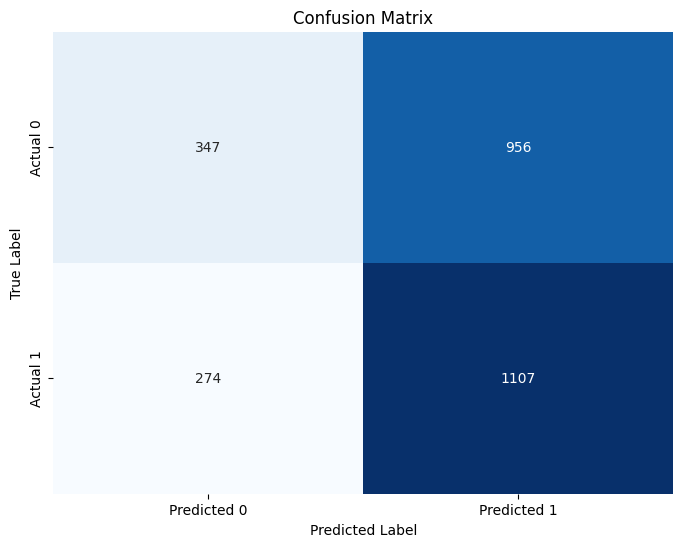

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test data
y_pred_probs = model.predict(padded_testing_sequences)

# Convert probabilities to binary predictions (0 or 1)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix helps us understand the types of errors made by the model:

*   **True Negatives (Top-Left)**: Correctly predicted 0 (negative class).
*   **False Positives (Top-Right)**: Incorrectly predicted 1 (positive class) when the actual was 0.
*   **False Negatives (Bottom-Left)**: Incorrectly predicted 0 (negative class) when the actual was 1.
*   **True Positives (Bottom-Right)**: Correctly predicted 1 (positive class).

By examining these values, you can gain insight into the specific strengths and weaknesses of your model's classification performance.